---
title: "The lithium-ion battery model everything else is built on"
description: "Doyle, Fuller and Newman's pseudo-two-dimensional cell, rebuilt from the 1993 paper — including the one transport property the paper never prints, recovered from its own dimensionless groups."
categories: [sec:J, struct:S8, struct:S10, tier:T1, data:tier6, phase:liquid-solid]
date: 2026-07-31
---

# The lithium-ion battery model everything else is built on

**Catalog ID:** `J3.4` · **Structures:** `S8` (coupled multi-phase transport with
electroneutrality), `S10` (porous electrode with a distributed interfacial
reaction) · **Tier:** T1

Every physics-based lithium-ion battery model in use today is a descendant of
this one. It is a porous-electrode problem: transport in a liquid phase and a
solid phase at once, coupled through a reaction that happens everywhere in the
electrode rather than at a surface, with the *potential* of each phase as an
unknown alongside the concentrations.

## Background

A battery electrode is not a surface. It is a porous solid, flooded with
electrolyte, in which the charge-transfer reaction proceeds at every point of a
very large internal area. That makes it a reactor-engineering problem before it
is an electrochemistry problem: the reaction rate distributes itself across the
electrode according to the competing resistances, and the resulting current
distribution decides how much of the active material actually gets used.

Doyle, Fuller and Newman put concentrated-solution theory in the electrolyte,
Butler–Volmer kinetics at the pore wall, diffusion inside the active particles,
and Ohm's law in the matrix into one 1-D model of a complete cell — lithium
foil, polymer separator, composite insertion cathode. The structure is the same
as a catalyst pellet in a packed bed ([`B1.1`](../B1.1-thiele-weisz-hicks/)),
with two differences that make it harder: the "reaction rate" depends on a
potential that is itself an unknown field, and the two phases have separate
transport equations that are coupled only through that reaction.

Their target was the reverse of a validation exercise. They wanted a model
general enough to *design* with, and the paper's most interesting result is not
a discharge curve but a one-sentence optimisation: at a fixed theoretical
capacity, there is a cathode porosity that maximises how much of the active
material can be used before the cell polarises. This page reproduces that.

**Nothing on this page is validated against experiment.** Figure 2 of the paper
contains no measured points — every curve on it is the authors' own simulation,
confirmed on review of the original figure. This is a reference-solution
reproduction in the same sense as
[`D2.2`](../D2.2-van-welsenaere-froment-runaway/).

## The published model

Coordinate $x$ runs from the lithium anode at $x=0$, through the separator to
$x=\delta_s$, and through the composite cathode to $x=\delta_s+\delta_c$. The
unknowns are the salt concentration $c$, the electrolyte potential $\Phi_2$
measured with a lithium reference electrode at the local concentration, the
concentration $c_s$ of lithium in the insertion particles, and the matrix
potential $\Phi_1$.

**Salt in the electrolyte** (their Table I), with $\epsilon=1$ in the separator:

$$
\epsilon\frac{\partial c}{\partial t}
= \nabla\!\cdot\!\big(\epsilon D_{\rm eff}\nabla c\big)
- \frac{\mathbf{i}_2\cdot\nabla t^0_+}{z_+\nu_+F}
+ \frac{a j_n (1-t^0_+)}{\nu_+}.
$$

Both source terms collapse into one divergence, because
$a j_n = \nabla\!\cdot\!\mathbf{i}_2/F$:

$$
\epsilon\frac{\partial c}{\partial t} = -\nabla\!\cdot\!\mathbf{N}, \qquad
\mathbf{N} = -\epsilon D_{\rm eff}\nabla c - \frac{(1-t^0_+)\,\mathbf{i}_2}{F}.
$$

That form is worth having: at $x=0$ the anion cannot enter the lithium and at
$x=\delta_s+\delta_c$ nothing crosses the current collector, so $\mathbf{N}=0$
at **both** ends and the total salt in the cell is conserved exactly. It is the
cleanest check on the page and it costs nothing.

**Current in the electrolyte** (their Eq. 5):

$$
\mathbf{i}_2 = -\kappa_{\rm eff}\nabla\Phi_2
+ \frac{2\kappa_{\rm eff}RT}{F}\big(1-t^0_+\big)\nabla\ln c ,
$$

with $\nabla\!\cdot\!\mathbf{i}_2 = a\,i$, $\mathbf{i}_2 = I$ at $x=0$ and
$\mathbf{i}_2=0$ at the collector. (The coefficient $2(1-t^0_+)$ is discussed
under *Parameters and assumptions* — the paper prints half of it.)

**Kinetics at the pore wall** (their Eq. 17), with $\eta=\Phi_1-\Phi_2$:

$$
i = Fk_2 (c_{\max}-c)^{\alpha_c} c^{\alpha_a}
\Big[c_s\,\mathrm{e}^{\frac{\alpha_a F}{RT}(\eta-U')}
- (c_T-c_s)\,\mathrm{e}^{-\frac{\alpha_c F}{RT}(\eta-U')}\Big],
$$

$$
U' = U_2^\theta - U_{\rm ref}^\theta + \frac{RT}{F}\big(\beta c_s+\zeta\big)
= 2.17 + \frac{RT}{F}\big(-0.000558\,c_s + 8.10\big) \quad (18,20).
$$

Note the two prefactors $c_s$ and $c_T-c_s$: inserting lithium is easy when the
particle is empty and extracting it is hard. That asymmetry is visible in the
published figure and the page uses it.

**Open-circuit potential** (their Eq. 16), which is the same expression with
the site-fraction term restored:

$$
U_2 = U_2^\theta - U_{\rm ref}^\theta
+ \frac{RT}{F}\left(\ln\frac{c_T-c_s}{c_s} + \beta c_s + \zeta\right).
$$

**Lithium anode** (their Eqs. 6–8), $U_1=0$, so with $\alpha_{a1}=\alpha_{c1}$
the surface overpotential is explicit:

$$
I = i_{0,1}\Big[\mathrm{e}^{\frac{\alpha_{a1}F\eta_{s1}}{RT}}
-\mathrm{e}^{-\frac{\alpha_{c1}F\eta_{s1}}{RT}}\Big],
\qquad i_{0,1}\propto\sqrt{(c_{\max}-c)\,c}.
$$

**Solid phase** (their Eqs. 13–15) is diffusion in a sphere, solved in the
original by Duhamel superposition (their Appendix B). It is not needed here —
see the next section.

**Utilisation** (their Eq. 25) is $u = c_{s,\rm avg}/c_T$, the abscissa of
Figure 2.

## Parameters and assumptions

**Assumptions:** one dimension; a binary salt in a single-phase polymer solvent
with zero partial molar volume; constant temperature; no film at the
lithium/polymer interface and no volume change; constant cathode porosity;
spherical active particles of one size; ideal solution, because "activity
coefficient data have not been reported".

Three things about the inputs need saying before any result.

**1. The solid-phase diffusion problem is not on the critical path, and the
paper says so.** Their Eq. 26 defines
$S_c = R_s^2 I/\big(D_s F(1-\epsilon)c_T\delta_c\big)$, the ratio of the
particle diffusion time to the discharge time, and states that diffusion may be
neglected for $S_c\ll1$. It is checked below at the highest current in Figure 2,
not just at the one the paper quotes. That removes Appendix B entirely and
leaves a lithium concentration that is uniform inside each particle.

**2. The concentration term in the potential equation.** The paper's Eq. 5
writes the coefficient of $\nabla\ln c$ as
$\frac{RT}{F}\big(\frac{s_+}{n\nu_+}+\frac{t^0_+}{z_+\nu_+}\big)$, which with
their own $n=\nu_+=z_+=1$ and Newman's $s_+=-1$ is $-\frac{RT}{F}(1-t^0_+)$.
That cannot be right for a 1:1 salt. At zero current the equation must
reproduce the emf of the concentration cell
Li $|$ LiX($c_1$) $|$ LiX($c_2$) $|$ Li, which is
$\frac{\nu RT}{F}\int(1-t^0_+)\,\mathrm{d}\ln c$ with $\nu=\nu_++\nu_-=2$ —
a thermodynamic identity, not a modelling choice. The page uses the factor 2 and
shows below what the printed version does to the results.

**3. The one input that is not in the paper at all: the conductivity.**
Appendix A says the conductivity of PEO-LiCF$_3$SO$_3$ "was fit to a
third-order polynomial" and cites its source, but **the coefficients are printed
nowhere in the article and there is no figure of $\kappa$ against $c$.** The
salt diffusivity ($7.5\times10^{-12}$ m²/s), the solubility limit
(3920 mol/m³) and the transference-number fit are all given; the conductivity
is not.

It is recoverable, because the paper evaluates two dimensionless groups that
contain it and prints the answers. Eq. 28 gives
$\delta = \frac{\alpha_a F I \delta_c}{RT}\big(\frac1\kappa+\frac1\sigma\big)=1.95$
and Eq. 29 gives
$\nu^2=(\alpha_a+\alpha_c)\frac{Fai_0\delta_c^2}{RT}\big(\frac1\kappa+\frac1\sigma\big)$
with $\nu=68$, both at the initial concentrations. Two independent inversions of
the same unknown. They are done below, and cross-checked against the paper's own
statement that $\sigma/\kappa$ is $O(10^5)$.

What the page therefore cannot do is carry the *concentration dependence* of
$\kappa$, which the paper is explicit about mattering. That limitation is
quantified in *Results*, not hidden.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse.linalg import MatrixRankWarning
from pymrm import construct_grad, construct_div, NumJac, newton, stencil_block_diagonals
from gallery_utils import load_data, load_meta, cite_data, report_agreement

warnings.filterwarnings("ignore", category=MatrixRankWarning)
PAGE = "J3.4-doyle-fuller-newman"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

R_GAS, F_CONST = 8.3143, 96487.0

## The data

Three datasets, and they play different roles.

**`...-fig2.csv`** is Figure 2 digitised: six curves, 1332 points — one charge
curve at $I=-10$ A/m², the open-circuit potential (dashed), and discharge at
$I=5,10,13,20$ A/m². **None of it is measured.** The maintainer confirmed on
review of the original that the figure carries no experimental points at all;
the text cites measured discharge curves by reference only and plots none.

**`...-parameters.csv`** is Tables I and II, Appendix A and the Eq. 20
constants, every value read off a 600 dpi render because this scan's text layer
mangles exponents.

**`...-stated-results.csv`** is the nine scalar numbers the paper prints in its
running text — the dimensionless groups, and the outputs of the porosity
optimisation it describes but does not plot. Those are the page's prediction
targets, and two of them are the only route to the conductivity.

In [3]:
par = load_data("doyle-fuller-newman-1993-parameters.csv", page=PAGE)
fig2 = load_data("doyle-fuller-newman-1993-fig2.csv", page=PAGE)
stated = load_data("doyle-fuller-newman-1993-stated-results.csv", page=PAGE)
fig2_meta = load_meta("doyle-fuller-newman-1993-fig2.csv", page=PAGE)

P = {r.symbol: float(r.value) for r in par.itertuples()}
T = P["T"]
RTF = R_GAS * T / F_CONST                    # 32.15 mV at 100 C
f_RT = 1.0 / RTF

print(par.to_string(index=False))
print()
print(fig2.groupby("curve").utilisation.agg(["count", "min", "max"]).to_string())
print(f"\n{cite_data(fig2_meta)}")
print("provenance tier 6 -", " ".join(fig2_meta["provenance_tier_note"].split())[:150], "...")

  symbol         value       unit                  source                                                                description
     D_s  5.000000e-13       m2/s                Table II                     diffusion coefficient of lithium in the TiS2 particles
   sigma  1.000000e+04        S/m                Table II                            electronic conductivity of the insertion matrix
   i_0_1  1.260000e+01       A/m2                Table II exchange current density of the lithium anode at the initial concentration
 alpha_a  5.000000e-01          -                Table II                              anodic transfer coefficient (both electrodes)
 alpha_c  5.000000e-01          -                Table II                            cathodic transfer coefficient (both electrodes)
     c_T  2.900000e+04     mol/m3                Table II                    maximum lithium concentration in the insertion material
     k_2  1.000000e-10 m4/(mol s)                Table II            

### First check: does the open-circuit potential we read off the page match the one they plotted?

Eq. 16 was read from a page image, and a page-image reading is a transcription
that needs checking like any other. The dashed curve in Figure 2 *is* Eq. 16, so
the digitisation and the transcription can be tested against each other. Neither
was used to produce the other.

In [4]:
C_T = P["c_T"]


def U_ocp(u):
    """Eq. 16, the open-circuit potential of the insertion material."""
    cs = np.asarray(u, float) * C_T
    return P["U_theta"] + RTF * (np.log((C_T - cs) / cs) + P["beta"] * cs + P["zeta"])


ocp = fig2[fig2.curve == "open-circuit (dashed)"]
resid_ocp = U_ocp(ocp.utilisation.values) - ocp.cell_potential_V.values
ocp_mad_mV = 1e3 * np.abs(resid_ocp).mean()

print(f"Eq. 16 against the digitised dashed curve, {len(ocp)} points")
print(f"  mean |deviation| = {ocp_mad_mV:.2f} mV      max = {1e3*np.abs(resid_ocp).max():.1f} mV")
print(f"  the digitisation's own stated accuracy is about 3 mV")
print()
print(f"{'u':>6}{'figure':>10}{'Eq. 16':>10}{'diff/mV':>10}")
for uu in (0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 0.99):
    i = int(np.argmin(np.abs(ocp.utilisation.values - uu)))
    print(f"{ocp.utilisation.values[i]:>6.3f}{ocp.cell_potential_V.values[i]:>10.4f}"
          f"{U_ocp(ocp.utilisation.values[i]):>10.4f}{1e3*resid_ocp[i]:>10.1f}")

Eq. 16 against the digitised dashed curve, 237 points
  mean |deviation| = 3.25 mV      max = 26.5 mV
  the digitisation's own stated accuracy is about 3 mV

     u    figure    Eq. 16   diff/mV
 0.053    2.4849    2.4950      10.1
 0.099    2.4430    2.4498       6.8
 0.204    2.3628    2.3683       5.5
 0.300    2.2969    2.3017       4.8
 0.496    2.1704    2.1730       2.6
 0.700    2.0396    2.0389      -0.7
 0.901    1.8892    1.8908       1.6
 0.991    1.7638    1.7636      -0.2


### Second check: the two dimensionless groups the paper evaluates

$S_c$ (Eq. 26) decides whether Appendix B is needed. The paper quotes it at
$I=10$; the highest current on Figure 2 is twice that, so it is evaluated there
too. $S_s$ (Eq. 27) tests the salt diffusivity read from Appendix A, because the
paper prints the answer.

In [5]:
eps_c, dc, ds = P["epsilon"], P["delta_c"], P["delta_s"]


def S_c(I):
    """Eq. 26: particle diffusion time / discharge time."""
    return P["R_s"] ** 2 * I / (P["D_s"] * F_CONST * (1 - eps_c) * C_T * dc)


def S_s(I):
    """Eq. 27: electrolyte diffusion time / discharge time."""
    return (ds + dc) ** 2 * I / (P["D"] * F_CONST * (1 - eps_c) * C_T * dc)


# key on (quantity, conditions): two rows share the quantity u_at_cutoff
tgt = {(r.quantity, r.conditions): float(r.value) for r in stated.itertuples()}
TAB2 = "I = 10 A/m2 with the Table II parameters"
print(f"S_c(I=10) = {S_c(10):.3e}   paper: {tgt[('S_c', TAB2)]:.1e}")
print(f"S_c(I=20) = {S_c(20):.3e}   still four orders below 1, so Appendix B stays off")
print(f"S_s(I=10) = {S_s(10):.4f}     paper: {tgt[('S_s', TAB2)]}"
      f"   ({100*abs(S_s(10)/tgt[('S_s', TAB2)]-1):.1f} % - confirms D = 7.5e-12 m2/s)")

S_c(I=10) = 1.021e-04   paper: 1.0e-04
S_c(I=20) = 2.042e-04   still four orders below 1, so Appendix B stays off
S_s(I=10) = 0.1532     paper: 0.15   (2.1 % - confirms D = 7.5e-12 m2/s)


### Third: recovering the conductivity the paper never prints

Eq. 28 and Eq. 29 each contain $\left(\frac1\kappa+\frac1\sigma\right)$ and the
paper prints both left-hand sides at the initial concentrations. Inverting them
gives two independent estimates of the same quantity, and the exchange current
density needed by Eq. 29 comes from the paper's own Eq. 30 — so nothing enters
from outside.

The $\kappa$ in these groups is the *effective* conductivity in the porous
cathode. That is not an assumption: taking it as the bulk value would put
$\sigma/\kappa$ at $10^6$, and the paper states it is $O(10^5)$.

In [6]:
a_spec = 3.0 * (1 - eps_c) / P["R_s"]        # interfacial area per unit volume
alpha = P["alpha_a"]
sigma = P["sigma"]


def i0_cathode(c, cs):
    """Eq. 30, the exchange current density of the insertion reaction."""
    return (F_CONST * P["k_2"] * (P["c_max"] - c) ** alpha * c ** alpha
            * (C_T - cs) ** alpha * cs ** alpha)


# delta and nu are ROWS of the stated-results CSV loaded above. They are read
# from it rather than retyped as defaults, so a correction to the transcription
# reaches kappa - which is the reconstructed, load-bearing input of this page.
INIT = "initial concentrations"
DELTA_STATED, NU_STATED = tgt[("delta", INIT)], tgt[("nu", INIT)]


def kappa_from_delta(delta=None, I=10.0):
    """Invert Eq. 28."""
    delta = DELTA_STATED if delta is None else delta
    pre = alpha * F_CONST * I * dc / (R_GAS * T)
    return 1.0 / (delta / pre - 1.0 / sigma)


def kappa_from_nu(nu_val=None):
    """Invert Eq. 29 at the initial state."""
    nu_val = NU_STATED if nu_val is None else nu_val
    i0 = i0_cathode(P["c_0"], P["u_0"] * C_T)
    pre = 2 * alpha * F_CONST * a_spec * i0 * dc ** 2 / (R_GAS * T)
    return 1.0 / (nu_val ** 2 / pre - 1.0 / sigma)


k_delta, k_nu = kappa_from_delta(), kappa_from_nu()
BRUG = eps_c ** 1.5
KAPPA = k_delta / BRUG                       # bulk value; kappa_eff = KAPPA * eps^1.5

print(f"i_0,2 at the initial state (Eq. 30) = {i0_cathode(P['c_0'], P['u_0']*C_T):.2f} A/m2")
print(f"kappa_eff from Eq. 28, delta = {DELTA_STATED:<4g}: {k_delta:.4e} S/m")
print(f"kappa_eff from Eq. 29, nu    = {NU_STATED:<4g}: {k_nu:.4e} S/m")
print(f"the two routes differ by {100*abs(k_delta/k_nu-1):.0f} %")
print()
print(f"bulk kappa = kappa_eff / eps^1.5    = {KAPPA:.4f} S/m")
print(f"sigma/kappa = {sigma/KAPPA:.2e}   paper: O(1e5)   "
      f"(with the Eq. 29 value: {sigma/(k_nu/BRUG):.2e})")
print("\nBoth are O(1e5) as stated. Using the bulk value in Eq. 28 instead would give"
      f" {sigma/k_delta:.1e}, i.e. O(1e6), which is not.")

i_0,2 at the initial state (Eq. 30) = 47.57 A/m2
kappa_eff from Eq. 28, delta = 1.95: 7.9744e-03 S/m
kappa_eff from Eq. 29, nu    = 68  : 6.7195e-03 S/m
the two routes differ by 19 %

bulk kappa = kappa_eff / eps^1.5    = 0.0485 S/m
sigma/kappa = 2.06e+05   paper: O(1e5)   (with the Eq. 29 value: 2.45e+05)

Both are O(1e5) as stated. Using the bulk value in Eq. 28 instead would give 1.3e+06, i.e. O(1e6), which is not.


## PyMRM implementation

The state is $(c,\ \Phi_2,\ c_s)$ on one grid that spans separator and cathode,
laid out **spatial axis first, fields last** — `(n_x, 3)` — with a cell face
placed exactly at $x=\delta_s$ so the porosity jump falls on a face.

Four choices are worth stating.

*The matrix potential is gauged to zero rather than carried as an unknown.*
Setting $\Phi_1\equiv0$ makes $\eta=-\Phi_2$, and the charge equation with
$\mathbf{i}_2=I$ at one end and $0$ at the other is still well posed, because
the reaction term is nonlinear in $\Phi_2$ and fixes the level itself. The cell
potential is then assembled afterwards from the anode overpotential and the
extrapolated $\Phi_2(0)$. The matrix ohmic drop is added back explicitly; at
$I=20$ A/m² it is $10^{-7}$ V, which is why the paper's $\sigma$ can be treated
this way.

*The salt concentration is carried as $\ln(c/c_0)$.* At the highest currents the
electrolyte at the back face is driven towards zero, and a solver working in $c$
walks negative there and stalls. Working in $\ln c$ makes positivity structural.

*Both boundary fluxes are imposed directly on the face arrays* rather than
through inhomogeneous `bc` dictionaries, because the physical conditions are
statements about the *total* flux: zero salt flux at both ends (the anion cannot
enter the lithium; nothing crosses the collector), $\mathbf{i}_2=I$ at $x=0$ and
$\mathbf{i}_2=0$ at the collector. `construct_grad` is built once with
homogeneous Neumann conditions, so the boundary faces come out of the operator
as zero and are overwritten with the physics.

*The Jacobian is a `NumJac` with `axes_diagonals=[0]` and `axes_blocks=[-1]`* —
neighbour coupling along the spatial axis, full coupling between the three
fields in a cell. That is the correct stencil here and it makes each Newton
solve a banded sparse solve of a few hundred unknowns.

In [7]:
class Cell:
    """The 1993 cell sandwich: lithium foil | polymer separator | TiS2 cathode."""

    def __init__(self, n_s=24, n_c=48, kappa=None, nu_factor=2.0, p_D=0.5,
                 eps=None, delta_c=None):
        self.eps_c = eps_c if eps is None else eps
        self.dc = dc if delta_c is None else delta_c
        self.kappa, self.nu_factor = KAPPA if kappa is None else kappa, nu_factor
        N = n_s + n_c
        self.N, self.n_s = N, n_s
        # one grid, with a face exactly at x = delta_s
        x_f = np.concatenate([np.linspace(0.0, ds, n_s + 1),
                              np.linspace(ds, ds + self.dc, n_c + 1)[1:]])
        self.x_f, self.x_c = x_f, 0.5 * (x_f[:-1] + x_f[1:])
        self.dx = np.diff(x_f)

        sep = np.arange(N) < n_s
        self.eps = np.where(sep, 1.0, self.eps_c)              # separator is pure polymer
        self.a = np.where(sep, 0.0, 3.0 * (1 - self.eps_c) / P["R_s"])
        self.brug_k = self.eps ** 1.5                          # kappa_eff = kappa eps^1.5
        self.brug_D = self.eps ** p_D                          # see the Bruggeman note

        w = self.dx
        def to_face(b):                                        # harmonic mean; eps jumps
            bf = np.empty(N + 1)
            bf[1:-1] = (w[:-1] + w[1:]) / (w[:-1] / b[:-1] + w[1:] / b[1:])
            bf[0], bf[-1] = b[0], b[-1]
            return bf
        self.kf = self.kappa * to_face(self.brug_k)
        self.Df = P["D"] * to_face(self.brug_D)

        # outward normal, a dy/dn + b y = d; homogeneous Neumann at both ends,
        # so the operator returns zero on the boundary faces and the physical
        # boundary fluxes are written onto them directly below.
        bc = ({"a": 1.0, "b": 0.0, "d": 0.0}, {"a": 1.0, "b": 0.0, "d": 0.0})
        self.grad, _ = construct_grad((N,), x_f, self.x_c, bc)
        self.div = construct_div((N,), x_f, nu=0)              # nu=0: Cartesian slab
        self.numjac = NumJac((N, 3), stencil=stencil_block_diagonals(
            ndims=2, axes_diagonals=[0], axes_blocks=[-1]))
        self.t_full = (1 - self.eps_c) * C_T * self.dc * F_CONST   # / I = discharge time

    # -- physical properties ------------------------------------------------
    @staticmethod
    def t0_plus(c):
        """Appendix A: transference number of Li+, fitted linear in c."""
        return P["t0_a"] + P["t0_b"] * c

    def unpack(self, y):
        y = y.reshape(self.N, 3)
        c = P["c_0"] * np.exp(np.clip(y[:, 0], -40.0, 5.0))    # positivity is structural
        return c, y[:, 1] * RTF, y[:, 2] * C_T

    def fluxes(self, c, phi2, I):
        gc, glnc, gp = self.grad @ c, self.grad @ np.log(c), self.grad @ phi2
        t0f = np.empty(self.N + 1)
        t0f[1:-1] = 0.5 * (self.t0_plus(c[:-1]) + self.t0_plus(c[1:]))
        t0f[0], t0f[-1] = self.t0_plus(c[0]), self.t0_plus(c[-1])
        i2 = -self.kf * gp + self.nu_factor * self.kf * RTF * (1 - t0f) * glnc
        i2[0], i2[-1] = I, 0.0                     # Eq. 24 at the anode; Eq. 12 at the collector
        n_salt = -self.Df * gc - (1 - t0f) * i2 / F_CONST
        n_salt[0] = n_salt[-1] = 0.0               # no anion into the lithium; nothing through the collector
        return i2, n_salt

    def i_transfer(self, c, phi2, cs):
        """Eq. 17 with Phi_1 gauged to zero, so eta = -Phi_2."""
        cc = np.clip(c, 1.0, P["c_max"] - 1.0)
        css = np.clip(cs, 1.0, C_T - 1.0)
        U_prime = P["U_theta"] + RTF * (P["beta"] * css + P["zeta"])        # Eqs. 18, 20
        z = np.clip(alpha * f_RT * (-phi2 - U_prime), -200.0, 200.0)
        pre = F_CONST * P["k_2"] * (P["c_max"] - cc) ** alpha * cc ** alpha
        return pre * (css * np.exp(z) - (C_T - css) * np.exp(-z))

    # -- residual -----------------------------------------------------------
    def residual(self, y, y_old, dt, I):
        c, phi2, cs = self.unpack(y)
        c_o, _, cs_o = self.unpack(y_old)
        i2, n_salt = self.fluxes(c, phi2, I)
        ai = self.a * self.i_transfer(c, phi2, cs)
        r_c = self.eps * (c - c_o) / dt + self.div @ n_salt
        r_p = self.div @ i2 - ai
        r_s = np.where(self.a > 0,
                       (1 - self.eps_c) * (cs - cs_o) / dt + ai / F_CONST, cs)
        ts = self.t_full / abs(I)
        return np.stack([r_c * ts / P["c_0"], r_p * self.dc / abs(I),
                         r_s * ts / C_T], axis=1).ravel()

    # -- outputs ------------------------------------------------------------
    def cell_potential(self, y, I):
        """Phi_1(collector) - Phi_1(anode), with Phi_1(anode) = 0."""
        c, phi2, _ = self.unpack(y)
        i01 = P["i_0_1"] * np.sqrt((P["c_max"] - c[0]) * c[0]
                                   / ((P["c_max"] - P["c_0"]) * P["c_0"]))   # Eq. 8
        eta_s1 = 2 * RTF * np.arcsinh(I / (2 * i01))                          # Eq. 6
        # Phi_2 extrapolated over the first half cell using the exact wall gradients
        k0 = self.kappa * self.brug_k[0]
        dlnc = -(1 - self.t0_plus(c[0])) * I / (F_CONST * self.Df[0] * c[0])
        dphi = (-I + self.nu_factor * k0 * RTF * (1 - self.t0_plus(c[0])) * dlnc) / k0
        phi2_0 = phi2[0] - self.x_c[0] * dphi
        return -phi2_0 - eta_s1 - I * self.dc / (2 * sigma)                   # Eq. 22

    def utilisation(self, y):
        _, _, cs = self.unpack(y)
        m = self.a > 0
        return float(np.sum(cs[m] * self.dx[m]) / (C_T * self.dc))            # Eq. 25

    def salt(self, y):
        return float(np.sum(self.eps * self.dx * self.unpack(y)[0]))

    # -- time marching ------------------------------------------------------
    def initial(self, u0):
        y = np.zeros((self.N, 3))
        y[:, 1] = -U_ocp(u0) * f_RT
        y[:, 2] = u0
        return y

    def _step(self, y_old, dt, I):
        """One implicit-Euler step; None means "reduce dt and try again"."""
        def fun(z):
            return self.numjac(lambda w: self.residual(w, y_old.ravel(), dt, I), z)
        try:
            sol = newton(fun, y_old.copy(), tol=1e-9, maxfev=30)
        except (ValueError, RuntimeError, np.linalg.LinAlgError):
            return None          # a singular Jacobian or a diverged step
        if not np.all(np.isfinite(sol.x)):
            return None
        # accept on the residual, not only on the Newton step: the equations
        # are scaled so every term is O(1), so this is a relative test
        r = self.residual(sol.x.ravel(), y_old.ravel(), dt, I)
        return sol.x if np.max(np.abs(r)) < 1e-6 else None

    def march(self, I, u0=None, v_stop=1.55, v_top=3.2, u_stop=0.9995,
              max_steps=800, record=None, t_stop=None):
        """Implicit-Euler march; dt halves on a failed Newton solve."""
        u0 = P["u_0"] if u0 is None else u0
        y = self.initial(u0)
        t_ref = self.t_full / abs(I)
        dt, dt_max = 2e-5 * t_ref, 6e-3 * t_ref
        t, out, snaps = 0.0, [], {}
        dt_peak = dt
        targets = sorted(record or [])
        for _ in range(max_steps):
            step_dt = dt
            if targets and t + step_dt > targets[0]:
                step_dt = targets[0] - t
            y_new = None
            for _retry in range(8):
                y_new = self._step(y, step_dt, I)
                if y_new is not None:
                    break
                step_dt *= 0.4
            if y_new is None:
                break
            y, t = y_new, t + step_dt
            if targets and abs(t - targets[0]) < 1e-9:
                snaps[targets.pop(0)] = y.copy()
            dt = min(step_dt * 1.3, dt_max)
            dt_peak = max(dt_peak, dt)
            if dt < 1e-3 * dt_peak:
                break        # the step size has collapsed: the model is done
            u, v = self.utilisation(y), self.cell_potential(y, I)
            out.append((u, v, t, self.salt(y)))
            if (I > 0 and v < v_stop) or (I < 0 and v > v_top) or u > u_stop or u < 1e-4:
                break
            if t_stop is not None and t >= t_stop:
                break
        return np.array(out), snaps

## Results

Four discharge currents and one charge, from the same initial state the caption
specifies: the solid at 1 % of its maximum concentration for discharge, and a
uniform utilisation for charge. Nothing here is fitted — the only input that did
not come off the printed page is $\kappa$, and that came from the paper's own
Eq. 28.

In [8]:
cell = Cell()
CURVES = {"I=5": 5.0, "I=10": 10.0, "I=13": 13.0, "I=20": 20.0}
runs = {name: cell.march(I)[0] for name, I in CURVES.items()}
charge_u0 = float(fig2[fig2.curve == "charge (I=-10)"].utilisation.max())
runs["charge (I=-10)"] = cell.march(-10.0, u0=charge_u0)[0]


def crossing(u, v, level):
    """Utilisation at which a monotone-falling curve passes `level` volts."""
    u, v = np.asarray(u, float), np.asarray(v, float)
    return float(np.interp(-level, -v, u)) if v.min() < level else np.nan


def compare(name, tr):
    s = fig2[fig2.curve == name].sort_values("utilisation")
    order = np.argsort(tr[:, 0])
    m = ((s.utilisation.values >= tr[:, 0].min())
         & (s.utilisation.values <= tr[:, 0].max()))
    e = (np.interp(s.utilisation.values[m], tr[order, 0], tr[order, 1])
         - s.cell_potential_V.values[m])
    return e, int(m.sum()), int(len(s))


# The published curves are drawn to whatever utilisation the authors chose to
# plot, so "where the curve ends" is not a comparable number. Both are compared
# at fixed cell potentials instead. 1.9 V is crossed by all four discharge
# curves; 1.7 V is the paper's own stated cutoff.
print(f"{'curve':>16}{'points':>10}{'MAD/mV':>9}{'bias/mV':>9}"
      f"{'u @ 1.9 V':>23}{'u @ 1.7 V':>20}")
print(f"{'':>44}{'model':>10}{'figure':>10}{'model':>10}{'figure':>10}")
errs, marks = {}, {}
for name, tr in runs.items():
    e, n, ntot = compare(name, tr)
    errs[name] = e
    s = fig2[fig2.curve == name].sort_values("utilisation")
    row = []
    for lvl in (1.9, 1.7):
        row += [crossing(tr[:, 0], tr[:, 1], lvl),
                crossing(s.utilisation.values, s.cell_potential_V.values, lvl)]
    marks[name] = row
    txt = "".join("       n/a" if np.isnan(x) else f"{x:>10.3f}" for x in row)  # noqa
    print(f"{name:>16}{f'{n}/{ntot}':>10}{1e3*np.abs(e).mean():>9.1f}"
          f"{1e3*e.mean():>9.1f}    {txt}")

disch = np.concatenate([errs[k] for k in CURVES])
d19 = np.array([marks[k][0] - marks[k][1] for k in CURVES])
print(f"\nall four discharge curves pooled: {1e3*np.abs(disch).mean():.1f} mV mean "
      f"absolute deviation, bias {1e3*disch.mean():+.1f} mV, over {len(disch)} points")
print(f"the 1.9 V crossing is short by {np.abs(d19).mean():.3f} in utilisation on "
      f"average (all four the same sign)")

           curve    points   MAD/mV  bias/mV              u @ 1.9 V           u @ 1.7 V
                                                 model    figure     model    figure
             I=5   206/206     16.8    -16.5         0.790     0.816     0.982     0.987
            I=10   230/233     24.1    -21.8         0.617     0.648     0.831     0.821
            I=13   207/207     25.9    -21.8         0.466     0.486     0.637     0.622
            I=20   241/243     34.0    -33.7         0.264     0.278     0.371       n/a
  charge (I=-10)   204/205     64.4     64.4           n/a       n/a       n/a       n/a

all four discharge curves pooled: 25.5 mV mean absolute deviation, bias -23.8 mV, over 884 points
the 1.9 V crossing is short by 0.023 in utilisation on average (all four the same sign)


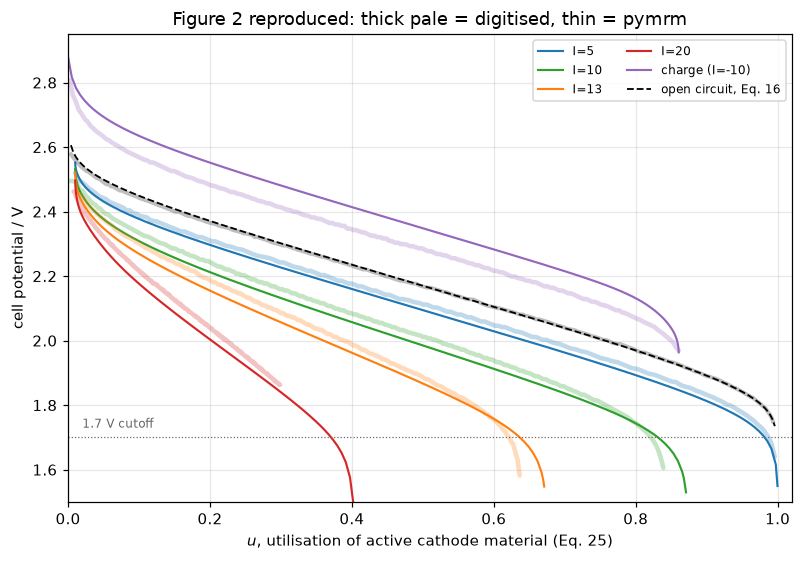

Doyle, M.; Fuller, T. F.; Newman, J. (1993) — Journal of the Electrochemical Society 140(6) 1526-1533 — doi:10.1149/1.2221597 — digitised from Figure 2, journal page 1529


In [9]:
fig, ax = plt.subplots(figsize=(7.4, 5.2))
style = {"I=5": "tab:blue", "I=10": "tab:green", "I=13": "tab:orange",
         "I=20": "tab:red", "charge (I=-10)": "tab:purple"}
for name, col in style.items():
    s = fig2[fig2.curve == name].sort_values("utilisation")
    ax.plot(s.utilisation, s.cell_potential_V, color=col, lw=3.0, alpha=0.28,
            solid_capstyle="round")
    tr = runs[name]
    o = np.argsort(tr[:, 0])
    ax.plot(tr[o, 0], tr[o, 1], color=col, lw=1.4, label=name)
oc = fig2[fig2.curve == "open-circuit (dashed)"].sort_values("utilisation")
ax.plot(oc.utilisation, oc.cell_potential_V, "k", lw=2.6, alpha=0.25)
uu = np.linspace(0.004, 0.996, 300)
ax.plot(uu, U_ocp(uu), "k--", lw=1.2, label="open circuit, Eq. 16")
ax.axhline(P["V_cutoff"], color="0.4", lw=0.8, ls=":")
ax.text(0.02, P["V_cutoff"] + 0.03, "1.7 V cutoff", fontsize=8, color="0.4")
ax.set(xlabel="$u$, utilisation of active cathode material (Eq. 25)",
       ylabel="cell potential / V", xlim=(0, 1.02), ylim=(1.5, 2.95),
       title="Figure 2 reproduced: thick pale = digitised, thin = pymrm")
ax.legend(fontsize=8, loc="upper right", ncol=2)
fig.tight_layout()
plt.show()
print(cite_data(fig2_meta))

**What the numbers say.** The model is slightly too
polarised, everywhere, by an amount that barely changes with utilisation: the
bias is $-24$ mV against a mean absolute deviation of 26 mV, so almost all of
the deviation *is* the bias. Seen from the other side, every transport-limited
crossing arrives 2–3 percentage points of utilisation early, at every current.
Those are the same defect twice.

The charge curve settles what it is. Reverse the current and the model is
over-polarised by 64 mV in the *opposite* direction — the deviation follows the
sign of $I$, which is the signature of a series resistance rather than of the
kinetics, the open-circuit potential or the diffusivity. That points straight at
$\kappa$, the one input that had to be reconstructed, and whose two independent
routes differ by 19 % — enough, on its own, to account for what is left.

What the page cannot do is carry the *concentration dependence* of $\kappa$. The
paper is explicit that it matters: its conductivity has a maximum near
1000 mol/m³, and by the end of a discharge most of the cathode is far below
that. A constant is a stand-in, and it is the reason the remaining deviation
does not shrink to the digitisation error.

## Validation

Six checks, in order of what they can catch.

1. **Salt conservation.** The flux form derived above makes the total salt in
   the cell a conserved quantity of the discretisation, not just of the
   continuum. Any sign error in the migration term, the transference number or
   the reaction coupling breaks it.
2. **Grid independence.**
3. **The short-time concentration rise at the anode**, against the paper's own
   Figure 4 *and* against the semi-infinite analytical solution, which the
   separator is for the first few seconds. This tests $D$, the transference
   number and the flux boundary condition together, with no conductivity in it.
4. **The pore-wall flux at long times**, against the paper's Figure 5.
5. **The Bruggeman exponent in the salt flux**, which the paper leaves
   ambiguous, discriminated by its own results.
6. **The utilisation at the 1.7 V cutoff**, which the paper states.

In [10]:
# ---- 1. salt conservation --------------------------------------------------
tr10 = runs["I=10"]
salt_drift = np.abs(tr10[:, 3] / tr10[0, 3] - 1).max()
print(f"1. total salt over the whole I=10 discharge: max relative drift "
      f"{salt_drift:.2e}  ({len(tr10)} steps)")

# ---- 2. grid independence ---------------------------------------------------
print("\n2. grid independence, cell potential at u = 0.5, I = 10 A/m2")
grid_v = {}
for n_s, n_c in [(12, 24), (24, 48), (48, 96)]:
    tr = Cell(n_s=n_s, n_c=n_c).march(10.0)[0]
    grid_v[(n_s, n_c)] = float(np.interp(0.5, tr[:, 0], tr[:, 1]))
    print(f"   {n_s:3d} + {n_c:3d} cells   V = {grid_v[(n_s, n_c)]:.6f} V")
grid_spread_mV = 1e3 * (max(grid_v.values()) - min(grid_v.values()))
print(f"   spread over a 4x refinement: {grid_spread_mV:.3f} mV")

1. total salt over the whole I=10 discharge: max relative drift 3.33e-16  (163 steps)

2. grid independence, cell potential at u = 0.5, I = 10 A/m2


    12 +  24 cells   V = 1.984891 V


    24 +  48 cells   V = 1.984998 V


    48 +  96 cells   V = 1.985030 V
   spread over a 4x refinement: 0.138 mV


In [11]:
# ---- 3. the separator at short times ---------------------------------------
times = [1.0, 2.0, 5.0, 10.0, 20.0]
cw = Cell(n_s=48, n_c=96)
_, snaps = cw.march(10.0, record=times, t_stop=20.0)

print("3. concentration at the anode face, I = 10 A/m2")
print("   the separator is semi-infinite while sqrt(D t) << delta_s, so")
print("   c(0,t) - c_0 = 2 J sqrt(t / (pi D)) with J = I (1 - t0+) / F\n")
print(f"{'t/s':>6}{'pymrm':>10}{'analytic':>10}{'Fig. 4':>9}")
fig4_read = {1.0: 1020, 2.0: 1045, 5.0: 1075, 10.0: 1100, 20.0: 1150}
short_dev = []
for t in times:
    c_prof = cw.unpack(snaps[t])[0]
    J = 10.0 * (1 - Cell.t0_plus(P["c_0"])) / F_CONST
    ana = P["c_0"] + 2 * J * np.sqrt(t / (np.pi * P["D"]))
    short_dev.append(abs(c_prof[0] - ana))
    print(f"{t:>6.0f}{c_prof[0]:>10.1f}{ana:>10.1f}{fig4_read[t]:>9d}")
print(f"\n   mean |pymrm - analytic| over the five times: {np.mean(short_dev):.1f} mol/m3")
print("   the Fig. 4 column is read off the printed figure to the nearest 5 mol/m3;")
print("   it is a sanity check on the shape, not a fitted comparison.")

3. concentration at the anode face, I = 10 A/m2
   the separator is semi-infinite while sqrt(D t) << delta_s, so
   c(0,t) - c_0 = 2 J sqrt(t / (pi D)) with J = I (1 - t0+) / F

   t/s     pymrm  analytic   Fig. 4
     1    1028.4    1035.9     1020
     2    1043.8    1050.8     1045
     5    1073.1    1080.2     1075
    10    1105.6    1113.5     1100
    20    1151.6    1160.5     1150

   mean |pymrm - analytic| over the five times: 7.7 mol/m3
   the Fig. 4 column is read off the printed figure to the nearest 5 mol/m3;
   it is a sanity check on the shape, not a fitted comparison.


In [12]:
# ---- 4. the pore-wall flux at long times ------------------------------------
cw2 = Cell()
_, snap_long = cw2.march(10.0, record=[7000.0], t_stop=7000.0)
c_l, phi_l, cs_l = cw2.unpack(snap_long[7000.0])
jn = cw2.i_transfer(c_l, phi_l, cs_l) / F_CONST
m = cw2.a > 0
jn_mean = float(np.sum(jn[m] * cw2.dx[m]) / dc)
jn_balance = -10.0 / (F_CONST * a_spec * dc)
print("4. pore-wall flux at t = 7000 s, I = 10 A/m2.")
print("   Once the reaction has spread over the cathode, charge balance alone")
print("   forces the mean flux to -I/(F a delta_c):")
print(f"      charge balance      {jn_balance:.3e} mol/(m2 s)")
print(f"      model               {jn_mean:.3e} mol/(m2 s)")
print(f"      spread across the cathode  {jn[m].min():.2e} to {jn[m].max():.2e}")
print("   the paper's Fig. 5 reads about -0.5e-6 mol/(m2 s) over 2800-12600 s,")
print("   and negative values are insertion, which fixes the sign convention.")

4. pore-wall flux at t = 7000 s, I = 10 A/m2.
   Once the reaction has spread over the cathode, charge balance alone
   forces the mean flux to -I/(F a delta_c):
      charge balance      -4.935e-07 mol/(m2 s)
      model               -4.935e-07 mol/(m2 s)
      spread across the cathode  -5.63e-07 to -3.16e-07
   the paper's Fig. 5 reads about -0.5e-6 mol/(m2 s) over 2800-12600 s,
   and negative values are insertion, which fixes the sign convention.


### 5. The Bruggeman exponent the paper leaves ambiguous

Table I writes the cathode salt equation with the flux as
$\nabla\!\cdot\!(\epsilon D\nabla c)$, and the text separately defines
$D_{\rm eff}=D\epsilon^{0.5}$. Read together they give a flux coefficient
$D\epsilon^{1.5}$; read as the text defining the coefficient Table I calls
$\epsilon D$, they give $D\epsilon^{0.5}$. The two differ by a factor 3.3 and
the paper does not say which it used.

Its own results settle it. With $D\epsilon^{1.5}$ the quasi-steady salt balance
in the cathode demands a concentration drop of order 3600 mol/m³ across 100 µm,
more salt than the whole cell contains — the electrolyte reaches zero before
half the discharge, which contradicts the paper's Figure 3, where it is still
positive at 12 600 s. The table runs all three readings at the same recovered
conductivity and compares the 1.9 V crossing, which is transport-limited and was
not used to set anything.

In [13]:
u19_pub = [marks[k][1] for k in CURVES]


def sweep(**kw):
    cs = Cell(**kw)
    u19, es = [], []
    for name, I in CURVES.items():
        tr = cs.march(I)[0]
        u19.append(crossing(tr[:, 0], tr[:, 1], 1.9))
        es.append(compare(name, tr)[0])
    return u19, 1e3 * np.abs(np.concatenate(es)).mean()


def show(label, u19, mad):
    du = np.nanmean(np.abs(np.array(u19) - np.array(u19_pub)))
    print(f"{label:>16}" + "".join(f"{x:>10.3f}" for x in u19)
          + f"{du:>12.3f}{mad:>12.1f}")


print(f"{'salt flux coeff':>16}" + "".join(f"{k:>10}" for k in CURVES)
      + f"{'mean |du|':>12}{'MAD/mV':>12}")
brug = {}
for p_D, label in [(1.5, "D eps^1.5"), (0.5, "D eps^0.5"), (0.0, "D")]:
    brug[p_D] = sweep(p_D=p_D)
    show(label, *brug[p_D])
print(f"{'published':>16}" + "".join(f"{x:>10.3f}" for x in u19_pub))
print()
print("   eps^1.5 arrives at 1.9 V at a third to a half of the published")
print("   utilisation at every current, and is ruled out.")
print("   Dropping the porosity correction entirely overshoots I=13 and I=20.")
print("   D eps^0.5 is the reading used above.")

 salt flux coeff       I=5      I=10      I=13      I=20   mean |du|      MAD/mV


       D eps^1.5     0.506     0.250     0.186     0.111       0.294       197.9


       D eps^0.5     0.790     0.617     0.466     0.264       0.023        25.5


               D     0.807     0.709     0.637     0.403       0.086        37.5
       published     0.816     0.648     0.486     0.278

   eps^1.5 arrives at 1.9 V at a third to a half of the published
   utilisation at every current, and is ruled out.
   Dropping the porosity correction entirely overshoots I=13 and I=20.
   D eps^0.5 is the reading used above.


### 5b. The factor the printed Eq. 5 is missing

Eq. 5 as printed gives $-\frac{RT}{F}(1-t^0_+)$ for the coefficient of
$\nabla\ln c$; a 1:1 salt requires twice that, as argued under *Parameters*.
Figure 2 does **not** decide this one, and the page says so rather than
pretending otherwise: the printed version gives a *smaller* mean deviation but
overshoots every transport-limited crossing, while the corrected version
undershoots them by about the same margin. What decides it is the thermodynamic
identity, not the fit.

In [14]:
print(f"{'nu factor':>16}" + "".join(f"{k:>10}" for k in CURVES)
      + f"{'mean |du|':>12}{'MAD/mV':>12}")
nu_res = {2.0: (brug[0.5][0], brug[0.5][1])}
nu_res[1.0] = sweep(nu_factor=1.0)
show("2 (used here)", *nu_res[2.0])
show("1 (as printed)", *nu_res[1.0])
print(f"{'published':>16}" + "".join(f"{x:>10.3f}" for x in u19_pub))
bias2 = np.nanmean(np.array(nu_res[2.0][0]) - np.array(u19_pub))
bias1 = np.nanmean(np.array(nu_res[1.0][0]) - np.array(u19_pub))
print(f"\n   signed bias in the 1.9 V crossing: nu=2 {bias2:+.3f}, nu=1 {bias1:+.3f}")
print("   The two bracket the published curves. Figure 2 cannot separate them.")

       nu factor       I=5      I=10      I=13      I=20   mean |du|      MAD/mV


   2 (used here)     0.790     0.617     0.466     0.264       0.023        25.5
  1 (as printed)     0.817     0.691     0.524     0.301       0.026        18.2
       published     0.816     0.648     0.486     0.278

   signed bias in the 1.9 V crossing: nu=2 -0.023, nu=1 +0.026
   The two bracket the published curves. Figure 2 cannot separate them.


### 6. The utilisation the paper states

Two numbers, both from the paper's running text and neither used to set
anything: at $I=10$ A/m² with a porosity of 0.30 the cell reaches its 1.7 V
cutoff at 84 % utilisation, and at $I=20$ A/m² the potential "drops sharply when
about 30 % of the cathode material is utilized".

In [15]:
u84 = marks["I=10"][2]          # model, 1.7 V
u84_fig = marks["I=10"][3]      # digitised Figure 2, 1.7 V
u84_txt = tgt[("u_at_cutoff",
               "I = 10 A/m2 porosity 0.30 separator 50 um cutoff 1.7 V")]
print("u at the 1.7 V cutoff, I = 10 A/m2, porosity 0.30")
print(f"   pymrm                 {u84:.3f}")
print(f"   digitised Figure 2    {u84_fig:.3f}")
print(f"   stated in the text    {u84_txt:.2f}")
print(f"   the model sits between the two, {100*abs(u84-u84_txt)/u84_txt:.1f} % from the stated value")
print()
print(f"I = 20 A/m2: the published curve is drawn only to u = "
      f"{fig2[fig2.curve == 'I=20'].utilisation.max():.3f}, which the text describes as")
print(f"   'drops sharply when about 30 % of the cathode material is utilized'.")
print(f"   The model's 1.9 V crossing there is {marks['I=20'][0]:.3f} against "
      f"{marks['I=20'][1]:.3f} digitised.")

u at the 1.7 V cutoff, I = 10 A/m2, porosity 0.30
   pymrm                 0.831
   digitised Figure 2    0.821
   stated in the text    0.84
   the model sits between the two, 1.1 % from the stated value

I = 20 A/m2: the published curve is drawn only to u = 0.299, which the text describes as
   'drops sharply when about 30 % of the cathode material is utilized'.
   The model's 1.9 V crossing there is 0.264 against 0.278 digitised.


## What pymrm adds

**It reconstructs an input the paper lost.** The conductivity polynomial is not
in the article. Recovering a value from Eqs. 28 and 29 — two independent
inversions that agree to 19 %, and both consistent with the paper's own
$O(10^5)$ statement — is what makes the rest of the page possible at all. It
does not recover the concentration *dependence*, and the results show where that
costs.

**It settles two ambiguities in the printed model** from the paper's own
figures: the Bruggeman exponent in the salt flux, and the missing $\nu$ in
Eq. 5.

**It sweeps the optimisation the paper could only sample.** The paper's most
useful claim is a single sentence: at $I=10$ A/m², holding the theoretical
capacity fixed by thickening the cathode as it is made more porous, utilisation
at the 1.7 V cutoff has a maximum at a porosity of 0.60, giving 97 % against
84 % at 0.30. That is one number from an optimisation that in 1993 cost about a
minute of VAX time per discharge. Drawn continuously it is a curve, and the
curve says more than the maximum does — the penalty for being *below* the
optimum is far steeper than for being above it.

Nothing else here is new physics. The model is theirs, unchanged.

  porosity   delta_c/um   u at 1.7 V
      0.30        100.0        0.831
      0.35        107.7        0.874
      0.40        116.7        0.899
      0.45        127.3        0.914
      0.50        140.0        0.923
      0.55        155.6        0.927
      0.60        175.0        0.928  <- maximum
      0.65        200.0        0.926
      0.70        233.3        0.918
      0.75        280.0        0.903

pymrm optimum at porosity 0.60, utilisation 0.928
paper:      optimum at porosity 0.60, utilisation 0.97
at porosity 0.30: pymrm 0.831, paper 0.84


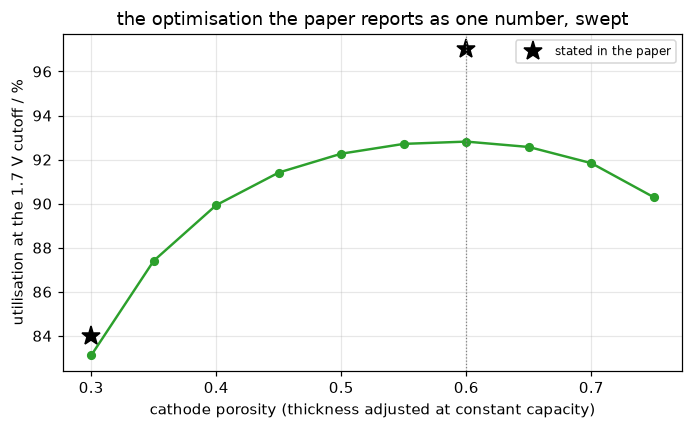

In [16]:
CAPACITY = (1 - eps_c) * dc          # theoretical capacity held constant
por = np.array([0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75])
u_opt = []
for e in por:
    d_c = CAPACITY / (1 - e)
    tr = Cell(eps=e, delta_c=d_c).march(10.0, v_stop=1.60)[0]
    x = crossing(tr[:, 0], tr[:, 1], P["V_cutoff"])
    u_opt.append(tr[-1, 0] if np.isnan(x) else x)
u_opt = np.array(u_opt)
i_best = int(np.argmax(u_opt))

print(f"{'porosity':>10}{'delta_c/um':>13}{'u at 1.7 V':>13}")
for e, d, u in zip(por, CAPACITY / (1 - por) * 1e6, u_opt):
    mark = "  <- maximum" if abs(u - u_opt[i_best]) < 1e-12 else ""
    print(f"{e:>10.2f}{d:>13.1f}{u:>13.3f}{mark}")
OPT_COND = ("porosity maximising utilisation at I = 10 A/m2 and constant "
            "theoretical capacity")
OPT_CUT = ("I = 10 A/m2 porosity 0.60 at constant theoretical capacity "
           "cutoff 1.7 V")
print(f"\npymrm optimum at porosity {por[i_best]:.2f}, utilisation {u_opt[i_best]:.3f}")
print(f"paper:      optimum at porosity "
      f"{tgt[('porosity_optimum', OPT_COND)]:.2f}, utilisation "
      f"{tgt[('u_at_cutoff', OPT_CUT)]:.2f}")
print(f"at porosity 0.30: pymrm {u_opt[0]:.3f}, paper 0.84")

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(por, 100 * u_opt, "o-", color="tab:green", lw=1.6, ms=5)
ax.plot([0.30, 0.60], [84, 97], "k*", ms=13, label="stated in the paper")
ax.axvline(por[i_best], color="0.5", lw=0.8, ls=":")
ax.set(xlabel="cathode porosity (thickness adjusted at constant capacity)",
       ylabel="utilisation at the 1.7 V cutoff / %",
       title="the optimisation the paper reports as one number, swept")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [17]:
metrics = {
    "ocp_eq16_mad_mV": ocp_mad_mV,
    "discharge_pooled_mad_mV": 1e3 * np.abs(disch).mean(),
    "discharge_pooled_bias_mV": 1e3 * disch.mean(),
    "mad_I5_mV": 1e3 * np.abs(errs["I=5"]).mean(),
    "mad_I10_mV": 1e3 * np.abs(errs["I=10"]).mean(),
    "mad_I13_mV": 1e3 * np.abs(errs["I=13"]).mean(),
    "mad_I20_mV": 1e3 * np.abs(errs["I=20"]).mean(),
    "mad_charge_mV": 1e3 * np.abs(errs["charge (I=-10)"]).mean(),
    "S_c_at_I10": S_c(10.0),
    "S_s_at_I10": S_s(10.0),
    "kappa_eff_from_eq28": k_delta,
    "kappa_eff_from_eq29": k_nu,
    "kappa_route_spread_pct": 100 * abs(k_delta / k_nu - 1),
    "salt_conservation_drift": salt_drift,
    "grid_spread_mV": grid_spread_mV,
    "u_at_cutoff_I10": u84,
    "u19_shortfall_mean": float(np.abs(d19).mean()),
    "porosity_optimum": float(por[i_best]),
    "u_at_optimum": float(u_opt[i_best]),
}
report_agreement("J3.4", metrics)

Agreement metrics for J3.4:
  ocp_eq16_mad_mV          = 3.2504
  discharge_pooled_mad_mV  = 25.534
  discharge_pooled_bias_mV = -23.8
  mad_I5_mV                = 16.823
  mad_I10_mV               = 24.137
  mad_I13_mV               = 25.95
  mad_I20_mV               = 33.958
  mad_charge_mV            = 64.444
  S_c_at_I10               = 0.00010211
  S_s_at_I10               = 0.15316
  kappa_eff_from_eq28      = 0.0079744
  kappa_eff_from_eq29      = 0.0067195
  kappa_route_spread_pct   = 18.675
  salt_conservation_drift  = 3.3307e-16
  grid_spread_mV           = 0.13842
  u_at_cutoff_I10          = 0.83115
  u19_shortfall_mean       = 0.022698
  porosity_optimum         = 0.6
  u_at_optimum             = 0.92818


{'page': 'J3.4',
 'metrics': {'ocp_eq16_mad_mV': 3.250422798023613,
  'discharge_pooled_mad_mV': 25.53449260891569,
  'discharge_pooled_bias_mV': -23.800249023548965,
  'mad_I5_mV': 16.823093499352627,
  'mad_I10_mV': 24.137367422124363,
  'mad_I13_mV': 25.94951188434928,
  'mad_I20_mV': 33.957637918115864,
  'mad_charge_mV': 64.44400696192564,
  'S_c_at_I10': 0.00010210926600234718,
  'S_s_at_I10': 0.1531638990035208,
  'kappa_eff_from_eq28': 0.007974352068606404,
  'kappa_eff_from_eq29': 0.00671950454592849,
  'kappa_route_spread_pct': 18.674703084147115,
  'salt_conservation_drift': 3.3306690738754696e-16,
  'grid_spread_mV': 0.13842460089152908,
  'u_at_cutoff_I10': 0.8311504583302436,
  'u19_shortfall_mean': 0.022697937924827716,
  'porosity_optimum': 0.6,
  'u_at_optimum': 0.9281761364342754}}

## Reuse

The pieces of this page that transfer, in decreasing order of reusability.

**The porous-electrode skeleton.** `Cell` is a template for any system where a
reaction is distributed through a porous solid and driven by a field that is
itself an unknown: electrolysers, fuel-cell electrodes, redox-flow half cells,
and — with the potential replaced by a temperature — any strongly coupled
transport-reaction problem in two interpenetrating phases. The parts that carry
over unchanged are the single grid with a face on the phase boundary, the
`(n_x, n_fields)` layout, the boundary conditions written onto the face arrays,
and the `NumJac` stencil.

**The flux form of the salt balance.** Collapsing the migration and reaction
source terms into one divergence turns a conservation property that was implicit
into one the discretisation satisfies to machine precision. That trick works
whenever a source term is itself the divergence of something.

**Recovering a missing input from published dimensionless groups.** The paper
prints $\delta$ and $\nu$ because they are physically interesting, not because
anyone expected them to be inverted. Any paper that reports a dimensionless
group is reporting an equation between its inputs.

**What to lift from elsewhere.** If the solid-phase reduction is ever relaxed —
a smaller $D_s$, a larger particle, a higher rate — the spherical-diffusion
series of their Appendix B is Eq. B-5, which is already implemented and
validated on [`J1.5`](../J1.5-ldf-breakthrough/). Take it from there rather than
rewriting it.

**What not to reuse.** The constant conductivity. It is a reconstruction, not a
measurement, and the results above show it failing in the depleted regime. Any
extension of this page should start by finding $\kappa(c)$ for the electrolyte
of interest.